In [1]:
import pandas as pd

df=pd.read_csv('/content/ai4i2020.csv')

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
df.shape

(10000, 14)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [36]:
print(f'пропусков в df: {df.isnull().sum().sum().item()}')

пропусков в df: 0


In [4]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


In [5]:
failure_types=['TWF',	'HDF',	'PWF',	'OSF',	'RNF']

df[failure_types].value_counts()

TWF  HDF  PWF  OSF  RNF
0    0    0    0    0      9652
     1    0    0    0       106
     0    1    0    0        80
          0    1    0        78
1    0    0    0    0        42
0    0    0    0    1        18
          1    1    0        11
     1    0    1    0         6
          1    0    0         3
1    0    0    1    0         2
               0    1         1
          1    1    0         1
Name: count, dtype: int64

In [6]:
df=df.drop(['UDI','Product ID'], axis=1)

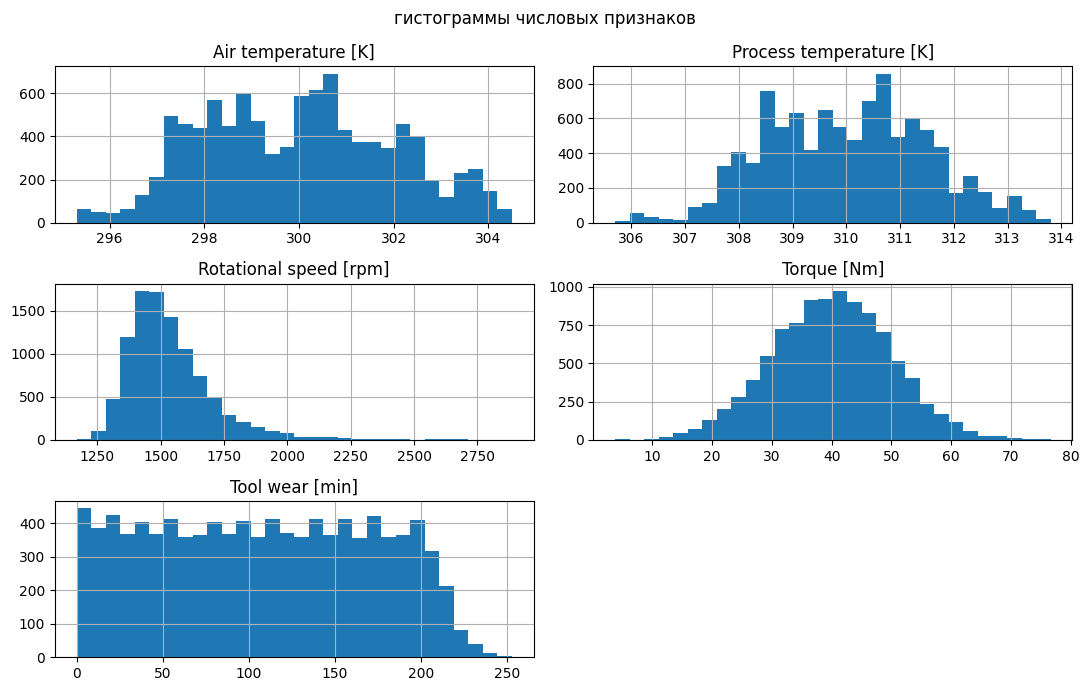

In [7]:
import matplotlib.pyplot as plt

num_cols=df.select_dtypes(include=['int64', 'float64']).columns.drop(['Machine failure',	'TWF',	'HDF', 'PWF',	'OSF',	'RNF'])
num_cols_targ=df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(bins=30, figsize=(11,7))
plt.suptitle('гистограммы числовых признаков')
plt.tight_layout()

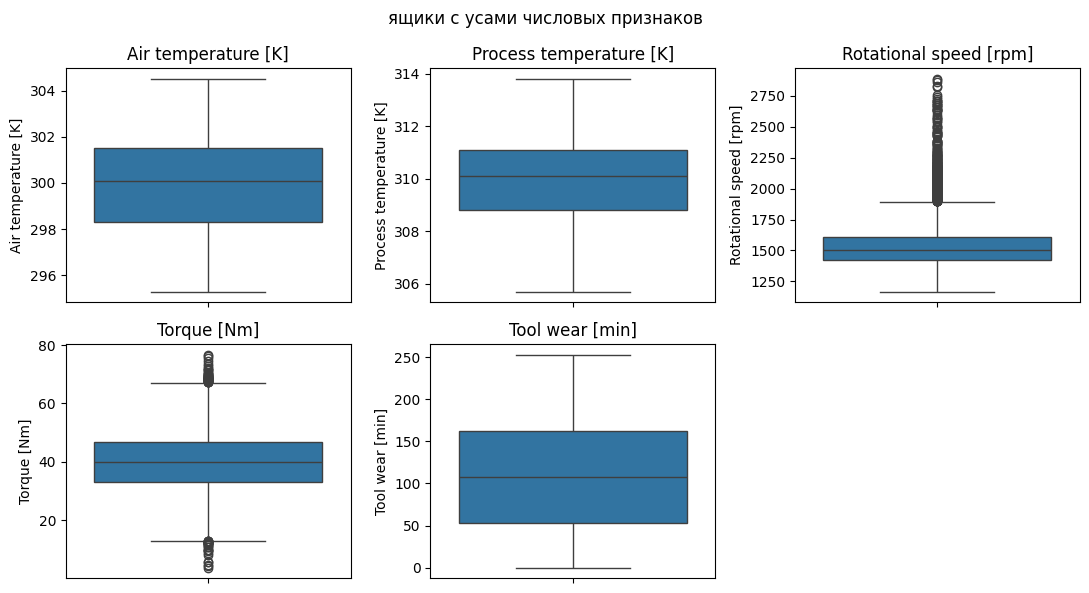

In [8]:
import seaborn as sns

plt.figure(figsize=(11, 6))
for i, col in enumerate(num_cols, 1):
  plt.subplot(2,3,i)
  sns.boxplot(data=df, y=col)
  plt.title(col)

plt.suptitle('ящики с усами числовых признаков')
plt.tight_layout()

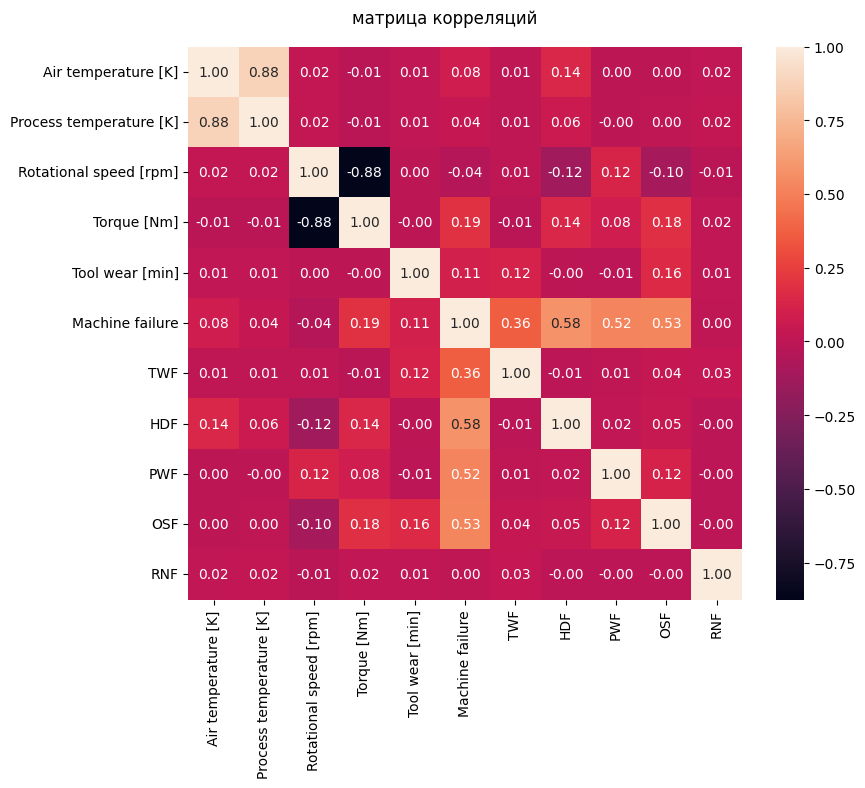

In [9]:
corr_m=df[num_cols_targ].corr()

plt.figure(figsize=(9,8))
sns.heatmap(corr_m, annot=True, fmt='.2f')
plt.suptitle('матрица корреляций')
features = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
plt.tight_layout()

In [10]:
# OSF зависит от порогов (L: 11000, M: 12000, H: 13000)
df['wear_torque_product']=df['Tool wear [min]'] * df['Torque [Nm]']

# для каждого типа свой порог
df['osf_threshold'] = df['Type'].map({'L': 11000, 'M': 12000, 'H': 13000})
df['osf_exceed'] = df['wear_torque_product'] > df['osf_threshold']

df=pd.get_dummies(df, columns=['Type'], prefix='type', drop_first=False)

# HDF происходит, если temp_diff < 8.6 K и скорость < 1380 rpm
df['temp_diff']=df['Process temperature [K]'] - df['Air temperature [K]']

# PWF происходит, если мощность < 3500 W или > 9000 W
df['power_approx']=df['Torque [Nm]'] * df['Rotational speed [rpm]']

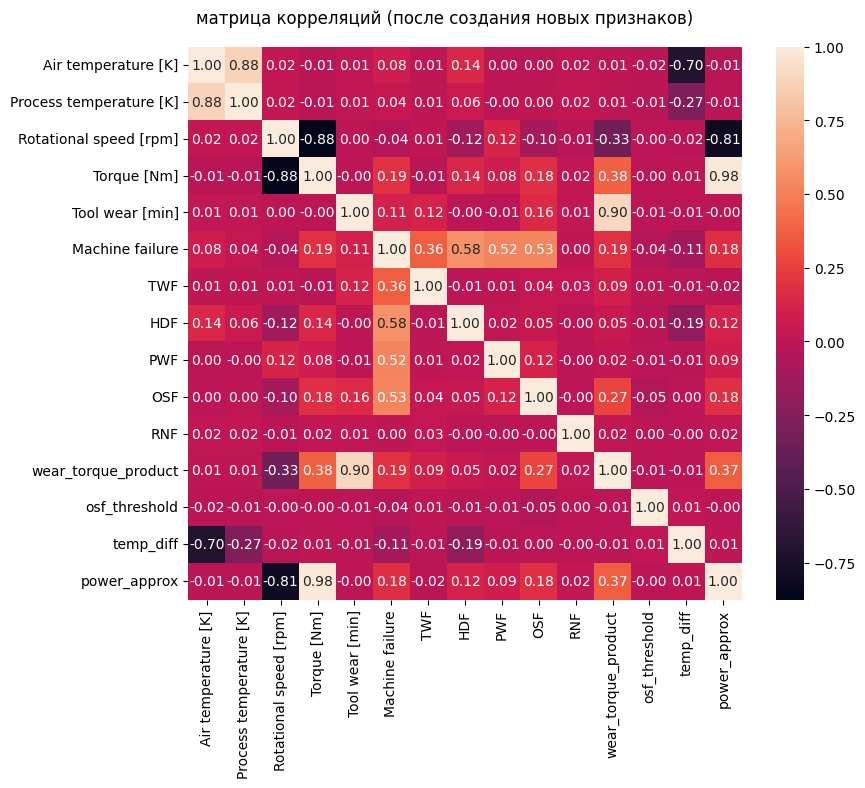

In [11]:
num_cols_targ_new = df.select_dtypes(include=['int64', 'float64']).columns

corr_m_new = df[num_cols_targ_new].corr()

plt.figure(figsize=(9, 8))
sns.heatmap(corr_m_new, annot=True, fmt='.2f')
plt.suptitle('матрица корреляций (после создания новых признаков)')
plt.tight_layout()

In [12]:
targets = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Machine failure']

feature_cols=[col for col in df.columns if col not in targets]

X=df[feature_cols]
y_bin=df['Machine failure']
y_mul=df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_bin_train, y_bin_test, y_mul_train, y_mul_test=train_test_split(
    X, y_bin, y_mul,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)

print(f'train size: {X_train.shape}')
print(f'test size: {X_test.shape}')

train size: (8000, 13)
test size: (2000, 13)


In [14]:
from sklearn.preprocessing import StandardScaler

cols_scale=['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
            'wear_torque_product', 'osf_threshold', 'osf_exceed', 'temp_diff']

scaler=StandardScaler()

X_train_scaled=X_train.copy()
X_test_scaled=X_test.copy()

X_train_scaled[cols_scale]=scaler.fit_transform(X_train[cols_scale])
X_test_scaled[cols_scale]=scaler.transform(X_test[cols_scale])

# переименовываем колонки (убираем скобки и пробелы)
X_train_scaled.columns = X_train_scaled.columns.str.replace('[', '').str.replace(']', '').str.replace(' ', '_')
X_test_scaled.columns = X_test_scaled.columns.str.replace('[', '').str.replace(']', '').str.replace(' ', '_')

In [17]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report


neg, pos= y_bin_train.value_counts()
scale_bin=neg/pos

param_grid_xgb={
    'n_estimators': [100,200,300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'scale_pos_weight': [scale_bin, scale_bin*2, scale_bin*3, scale_bin*5],
    'subsample':[0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

grid_xgb=GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid_xgb,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_xgb.fit(X_train_scaled,y_bin_train)
bin_model_xgb=grid_xgb.best_estimator_

mul_model_xgb=MultiOutputClassifier(
    XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05,
                  random_state=42, eval_metric='logloss')
)
mul_model_xgb.fit(X_train_scaled, y_mul_train)

print(f'XGB лучшие параметры: {grid_xgb.best_params_}\n')

y_bin_pred_xgb=bin_model_xgb.predict(X_test_scaled)
print(classification_report(y_bin_test, y_bin_pred_xgb))

y_mul_pred_xgb=mul_model_xgb.predict(X_test_scaled)
for i, f in enumerate(['TWF','HDF','PWF','OSF','RNF']):
  print(f'\n{f}:\n{classification_report(y_mul_test.iloc[:,i], y_mul_pred_xgb[:,i], zero_division=0)}')


XGB лучшие параметры: {'colsample_bytree': 0.9, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300, 'scale_pos_weight': 28.52029520295203, 'subsample': 0.8}

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1932
           1       0.69      0.87      0.77        68

    accuracy                           0.98      2000
   macro avg       0.84      0.93      0.88      2000
weighted avg       0.99      0.98      0.98      2000


TWF:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1990
           1       0.00      0.00      0.00        10

    accuracy                           0.99      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.99      0.99      0.99      2000


HDF:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1971
           1       0.93      0.97      0.95        29

    

In [19]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 4.9 MB/s eta 0:00:00


In [20]:
from catboost import CatBoostClassifier

param_grid_cat={
    'iterations': [100,200,300],
    'depth': [3,5,7],
    'learning_rate':[0.01,0.05,0.1],
    'class_weights':[{0:1, 1: scale_bin}, {0:1, 1: scale_bin*2}, {0:1, 1:scale_bin*3}, {0:1, 1: scale_bin*5}]
}

grid_cat=GridSearchCV(
    CatBoostClassifier(random_seed=42, verbose=0),
    param_grid_cat,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_cat.fit(X_train_scaled, y_bin_train)
bin_model_cat=grid_cat.best_estimator_

mul_model_cat=MultiOutputClassifier(
    CatBoostClassifier(iterations=150, depth=4, learning_rate=0.05, random_seed=42, verbose=0)
)
mul_model_cat.fit(X_train_scaled, y_mul_train)

print(f'CatBoost лучшие параметры:  {grid_cat.best_params_}')

y_bin_pred_cat=bin_model_cat.predict(X_test_scaled)
print(f'\n{classification_report(y_bin_test, y_bin_pred_cat)}')

y_mul_pred_cat=mul_model_cat.predict(X_test_scaled)
for i, f in enumerate(['TWF','HDF','PWF','OSF','RNF']):
  print(f'\n{f}\n{classification_report(y_mul_test.iloc[:,i], y_mul_pred_cat[:,i], zero_division=0)}')

CatBoost лучшие параметры:  {'class_weights': {0: 1, 1: 57.04059040590406}, 'depth': 3, 'iterations': 300, 'learning_rate': 0.05}

              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1932
           1       0.36      0.94      0.52        68

    accuracy                           0.94      2000
   macro avg       0.68      0.94      0.74      2000
weighted avg       0.98      0.94      0.95      2000


TWF
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1990
           1       0.00      0.00      0.00        10

    accuracy                           0.99      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.99      0.99      0.99      2000


HDF
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1971
           1       0.93      0.90      0.91        29

    accuracy                           1.

In [23]:
from lightgbm import LGBMClassifier

param_grid_lgb={
    'n_estimators': [100,200,300],
    'max_depth':[3,5,7],
    'learning_rate':[0.01, 0.05, 0.1],
    'scale_pos_weight': [scale_bin, scale_bin*2, scale_bin*3, scale_bin*5],
    'subsample':[0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

grid_lgb=GridSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_grid_lgb,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_lgb.fit(X_train_scaled, y_bin_train)
bin_model_lgb=grid_lgb.best_estimator_

mul_model_lgb=MultiOutputClassifier(
    LGBMClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42, verbose=-1)
)
mul_model_lgb.fit(X_train_scaled, y_mul_train)

print(f'LightGBM лучшие параметры: {grid_lgb.best_params_}\n')

y_bin_pred_lgb = bin_model_lgb.predict(X_test_scaled)
print(classification_report(y_bin_test, y_bin_pred_lgb))

y_mul_pred_lgb=mul_model_lgb.predict(X_test_scaled)
for i,f in enumerate(['TWF','HDF','PWF','OSF','RNF']):
  print(f'\n{f}:\n{classification_report(y_mul_test.iloc[:,i], y_mul_pred_lgb[:,i], zero_division=0)}')

LightGBM лучшие параметры: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 28.52029520295203, 'subsample': 0.7}

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1932
           1       0.44      0.90      0.59        68

    accuracy                           0.96      2000
   macro avg       0.72      0.93      0.79      2000
weighted avg       0.98      0.96      0.96      2000


TWF:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1990
           1       0.00      0.00      0.00        10

    accuracy                           0.99      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.99      0.99      0.99      2000


HDF:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1971
           1       1.00      1.00      1.00        29


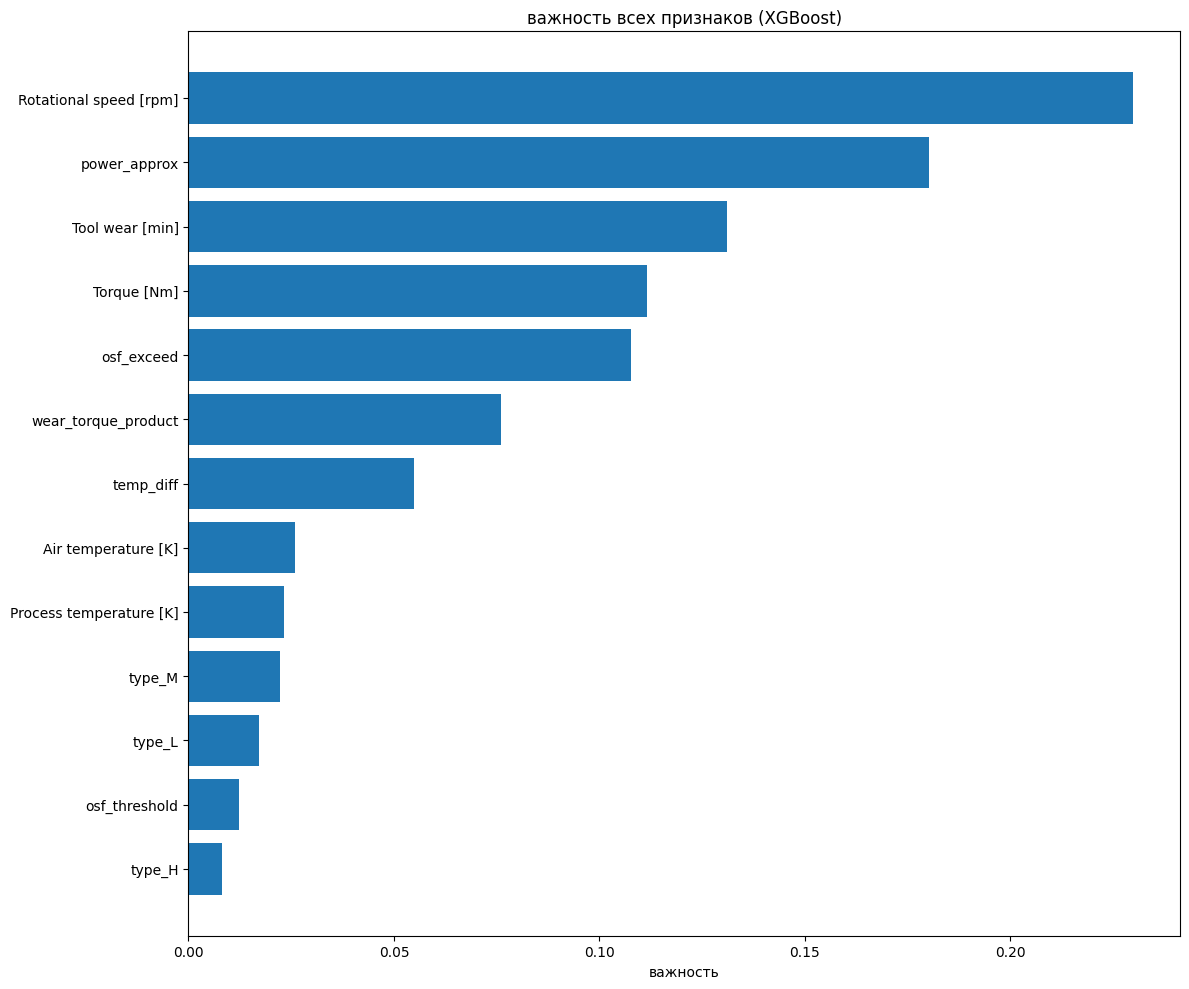

In [28]:
importances_bin_xgb=bin_model_xgb.feature_importances_

sorted_idx=sorted(zip(X_train.columns, importances_bin_xgb), key=lambda x:x[1])
names, vals=zip(*sorted_idx)

plt.figure(figsize=(12,10))
plt.barh(names, vals)
plt.xlabel('важность')
plt.title('важность всех признаков (XGBoost)')
plt.tight_layout()

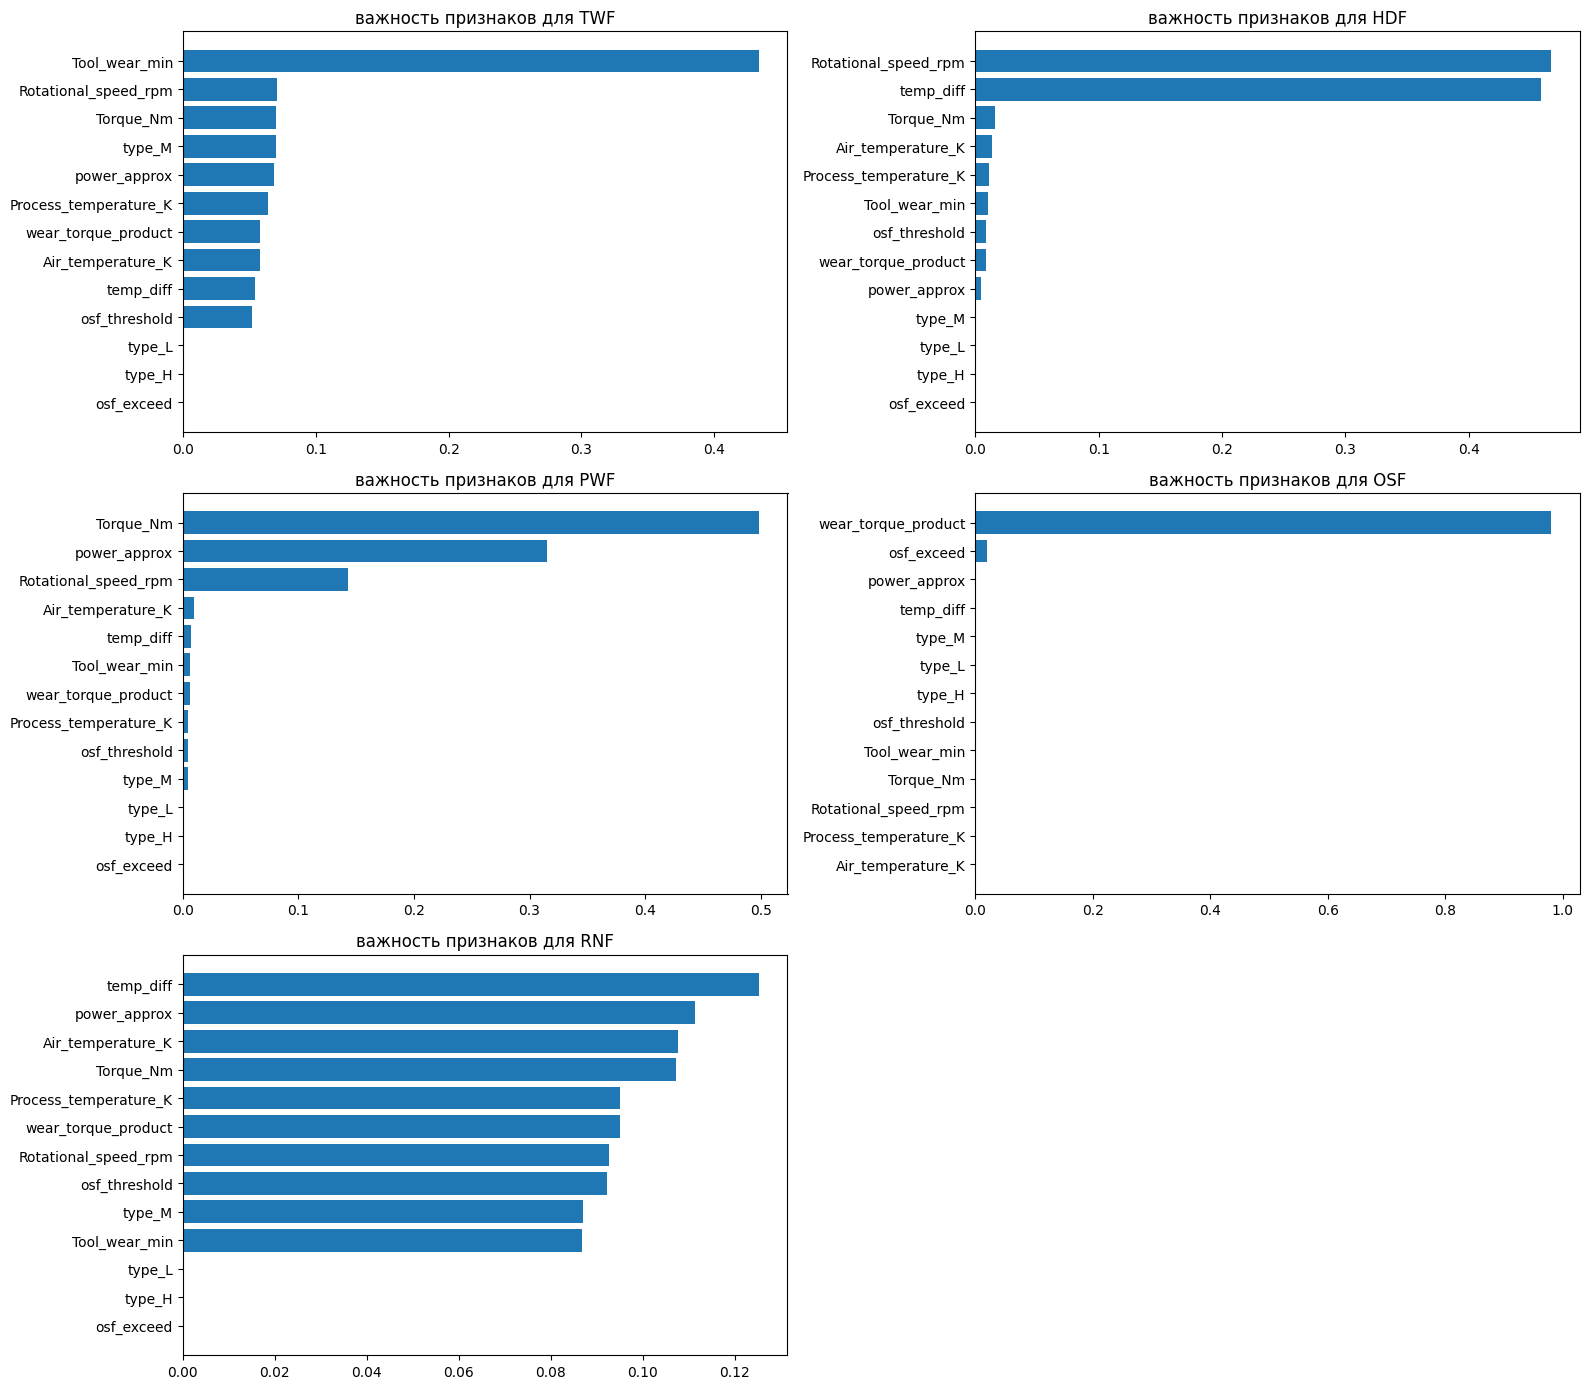

In [34]:
fig, axes=plt.subplots(3,2, figsize=(16,14))
axes=axes.flatten()

for i,f in enumerate(['TWF','HDF','PWF','OSF','RNF']):
  importances=mul_model_xgb.estimators_[i].feature_importances_
  sorted_idx=sorted(zip(X_train_scaled.columns, importances), key=lambda x: x[1])
  names, vals=zip(*sorted_idx)

  axes[i].barh(names, vals)
  axes[i].set_title(f'важность признаков для {f}')

axes[5].axis('off')
plt.tight_layout()